In [2]:
import nest_asyncio
nest_asyncio.apply()

from wakis import WakeSolver
from wakis import SolverFIT3D
#from wakis import GridFIT3D 
#from  clara_gridFIT3D_markCellsinSTL_WIP import GridFIT3D
#from wakis import clara_gridFIT3D_markCellsinSTL_WIP 
from wakis.clara_gridFIT3D_markCellsinSTL_WIP import GridFIT3D

import numpy as np
import pyvista as pv

from pyvista.trame.jupyter import launch_server
await launch_server().ready

pv.set_jupyter_backend('html') 
#pv.set_jupyter_backend('trame') 

from benchmark import benchmark

import pickle


import matplotlib.pyplot as plt
import scienceplots 
plt.style.use(['science', 'notebook','no-latex'])
#plt.style.use(['science', 'no-latex']) #smaller font size, good for plotting in papers?
#plt.style.use(['science', 'nature','no-latex'])  #very small font size, good for plotting in papers? , but not for jupyter notebooks & presentations.

In [3]:
stl_cavity = 'examples/data/001_vacuum_cavity.stl' 
stl_shell = 'examples/data/001_lossymetal_shell.stl' 
surf_shell=pv.read(stl_shell) 
surf_cavity=pv.read(stl_cavity) 
#stl_solids = {'cavity': stl_cavity, 'shell': stl_shell}
#stl_materials = {'cavity': 'vacuum', 'shell': [30, 1.0, 30]}

surf = pv.read(stl_shell) + pv.read(stl_cavity)
xmin, xmax, ymin, ymax, zmin, zmax = surf.bounds
Lx, Ly, Lz = (xmax-xmin), (ymax-ymin), (zmax-zmin)
print(f"Bounds: {surf.bounds}, Lx: {Lx}, Ly: {Ly}, Lz: {Lz}")
stl_tol=1e-3

Bounds: BoundsTuple(x_min = -0.25999999046325684,
            x_max =  0.25999999046325684,
            y_min = -0.25999999046325684,
            y_max =  0.25999999046325684,
            z_min = -0.25,
            z_max =  0.550000011920929), Lx: 0.5199999809265137, Ly: 0.5199999809265137, Lz: 0.800000011920929


In [4]:
resolutions = ['25x25x50', '50x50x100','100x100x200', '125x125x250', '150x150x300', '175x175x350'] 

for r in resolutions:
    Nx, Ny, Nz = int(r.split('x')[0]), int(r.split('x')[1]), int(r.split('x')[2]) 
    spacing=[(xmax - xmin) / Nx, (ymax - ymin) / Ny, (zmax - zmin) / Nz]
    x,y,z = np.linspace(xmin, xmax, Nx), np.linspace(ymin, ymax, Ny), np.linspace(zmin, zmax, Nz)
    stl_tolerance = np.min([np.min(np.diff(x)), np.min(np.diff(y)), np.min(np.diff(z))]) *stl_tol
    print(f"for resulution {r}, the spacing is {spacing}, and the stl tolerance is {stl_tolerance}")

for resulution 25x25x50, the spacing is [0.020799999237060548, 0.020799999237060548, 0.01600000023841858], and the stl tolerance is 1.6326530855529154e-05
for resulution 50x50x100, the spacing is [0.010399999618530274, 0.010399999618530274, 0.00800000011920929], and the stl tolerance is 8.080808201221478e-06
for resulution 100x100x200, the spacing is [0.005199999809265137, 0.005199999809265137, 0.004000000059604645], and the stl tolerance is 4.020100562416639e-06
for resulution 125x125x250, the spacing is [0.004159999847412109, 0.004159999847412109, 0.0032000000476837156], and the stl tolerance is 3.2128514534977006e-06
for resulution 150x150x300, the spacing is [0.0034666665395100913, 0.0034666665395100913, 0.0026666667064030964], and the stl tolerance is 2.6755853241502424e-06
for resulution 175x175x350, the spacing is [0.002971428462437221, 0.002971428462437221, 0.0022857143197740825], and the stl tolerance is 2.2922636444725477e-06


Plot of stl_tolerance vs resolution, and spacing vs resolution, to see how they change with resolution.

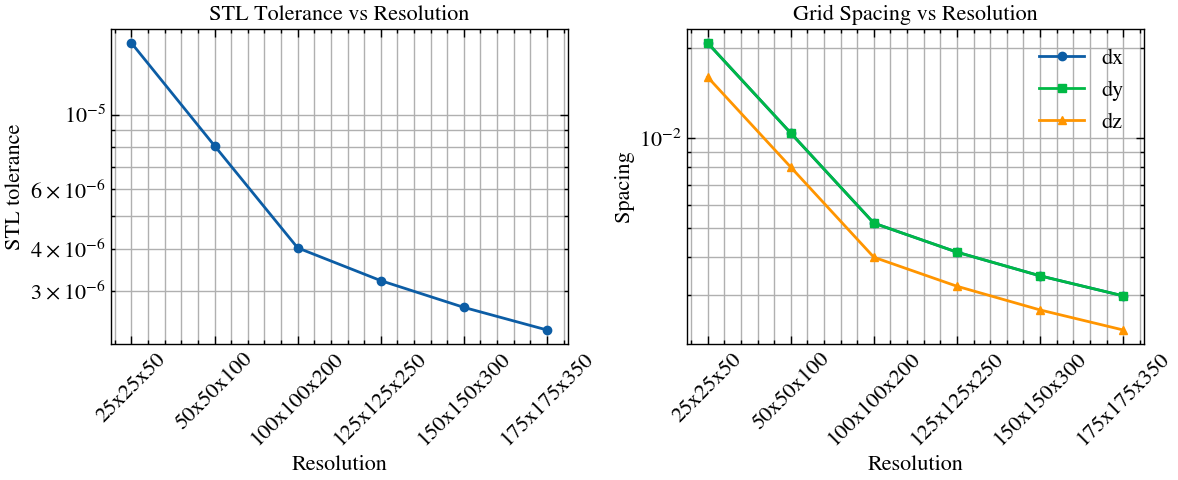

In [4]:




resolutions = ['25x25x50', '50x50x100','100x100x200', '125x125x250', '150x150x300', '175x175x350'] 

spacing_vals = []
stl_tol_vals = []
for r in resolutions:
    Nx, Ny, Nz = int(r.split('x')[0]), int(r.split('x')[1]), int(r.split('x')[2])
    spacing = [(xmax - xmin) / Nx, (ymax - ymin) / Ny, (zmax - zmin) / Nz]
    spacing_vals.append(spacing)
    x,y,z = np.linspace(xmin, xmax, Nx), np.linspace(ymin, ymax, Ny), np.linspace(zmin, zmax, Nz)
    stl_tolerance = np.min([np.min(np.diff(x)), np.min(np.diff(y)), np.min(np.diff(z))]) *stl_tol
    stl_tol_vals.append(stl_tolerance)

#for plotting
spacing_vals = np.array(spacing_vals)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(resolutions, stl_tol_vals, marker='o')
ax[0].set_yscale('log')
ax[0].set_xlabel('Resolution')
ax[0].set_ylabel('STL tolerance')
ax[0].set_title('STL Tolerance vs Resolution')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(True, which='both', ls='-')

# plot spacing components vs resolution
ax[1].plot(resolutions, spacing_vals[:,0], marker='o', label='dx')
ax[1].plot(resolutions, spacing_vals[:,1], marker='s', label='dy')
ax[1].plot(resolutions, spacing_vals[:,2], marker='^', label='dz')
ax[1].set_yscale('log')
ax[1].set_xlabel('Resolution')
ax[1].set_ylabel('Spacing')
ax[1].set_title('Grid Spacing vs Resolution')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()
ax[1].grid(True, which='both', ls='-')

plt.tight_layout()
plt.show()



# select_interior_points(method='cell_locator')

/tmp/cwimmelm/ipykernel_74781/482615721.py:29: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  ray_dummy1 = pv.PolyData([point_inside])
/tmp/cwimmelm/ipykernel_74781/482615721.py:32: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  plotter1.add_mesh(pv.PolyData(point_inside), color='green', point_size=20, label=f'Point (Inside: {is_inside})')


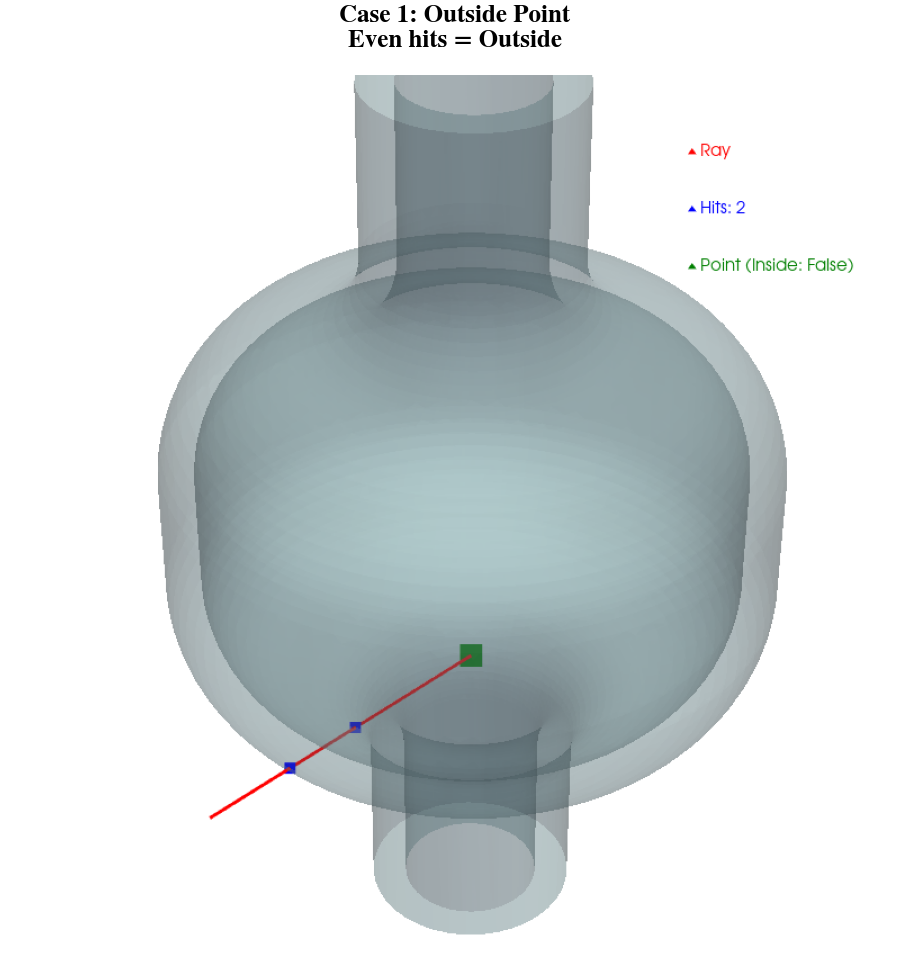

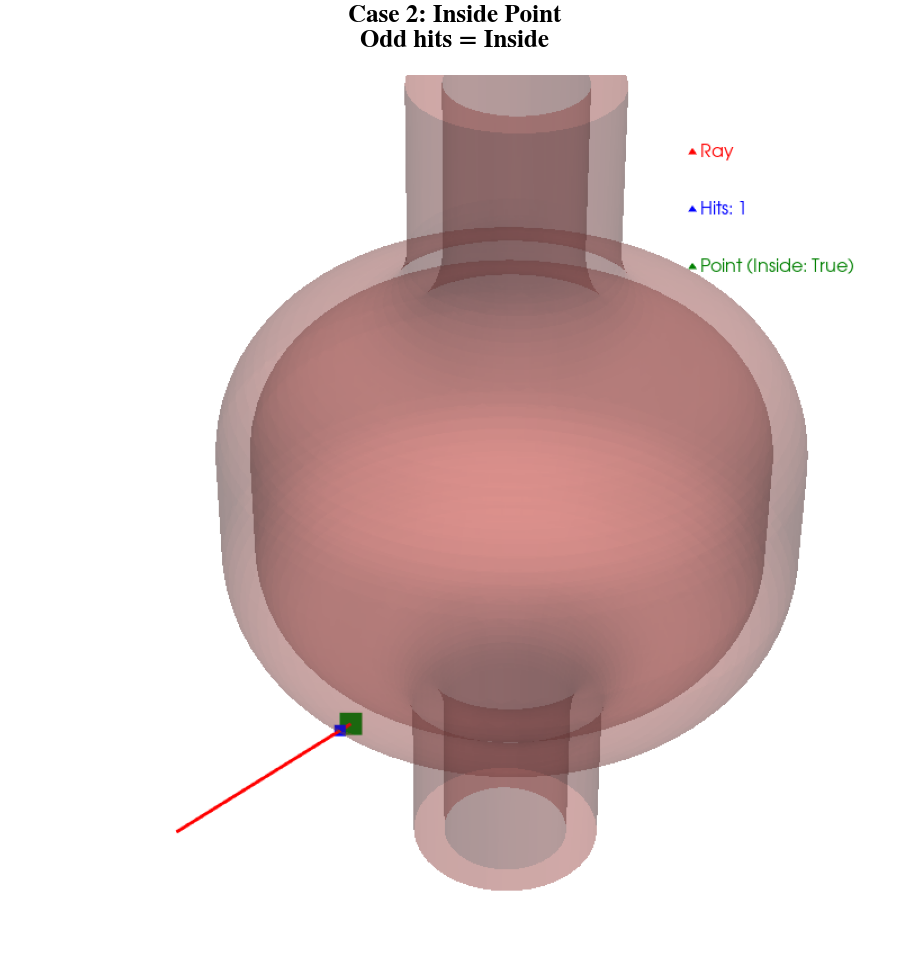

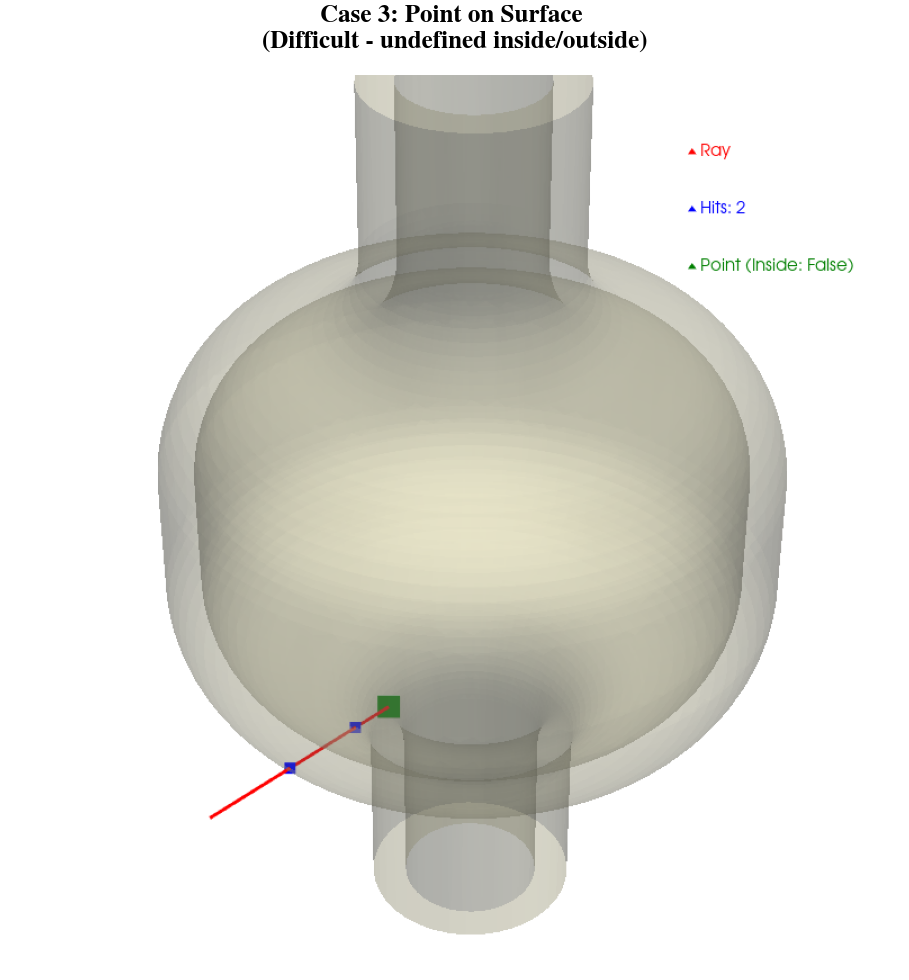

In [47]:
surface = surf_shell

# Test Case 1: Point inside the shell
point_inside = np.array([0, 0, 0])
ray_direction = np.array([0.3, 0, 0])
points_inside, ind_inside = surface.ray_trace(point_inside, ray_direction)
is_inside = len(points_inside) % 2 == 1  # Odd number of hits = inside

# Test Case 2: Point outside the shell  
point_outside = np.array([0.2, 0, 0])
ray_direction2 = np.array([0.4, 0, 0])
points_outside, ind_outside = surface.ray_trace(point_outside, ray_direction2)
is_outside = len(points_outside) % 2 == 1  # Odd number of hits = inside

# Test Case 3: Difficult case - point ON the surface (problematic for inside/outside tests)
point_edge = np.array([0.1, 0.0, 0.0])  # Exactly on the surface boundary
ray_direction3 = np.array([0.3, 0, 0])
points_edge, ind_edge = surface.ray_trace(point_edge, ray_direction3)
is_edge = len(points_edge) % 2 == 1  # Odd number of hits = inside

# Visualize Case 1: Inside Point
# Visualize Case 1: Inside Point
fig1 = plt.figure(figsize=(10, 10))
ax1 = fig1.add_subplot(111)
plotter1 = pv.Plotter(off_screen=True, window_size=(800, 800))
plotter1.add_mesh(surface, opacity=0.3, color='lightblue')
# Add ray line without label, then add dummy mesh for legend
plotter1.add_lines(np.array([point_inside, ray_direction]), color='red', width=3)
ray_dummy1 = pv.PolyData([point_inside])
plotter1.add_mesh(ray_dummy1, color='red', point_size=0, label='Ray', opacity=0)  # Invisible but in legend
plotter1.add_mesh(pv.PolyData(points_inside), color='blue', point_size=10, label=f'Hits: {len(points_inside)}')
plotter1.add_mesh(pv.PolyData(point_inside), color='green', point_size=20, label=f'Point (Inside: {is_inside})')
plotter1.add_legend()
plotter1.camera.zoom(1.5)  # Zoom in closer to the surface
img1 = plotter1.screenshot()
ax1.imshow(img1)
ax1.set_title("Case 1: Outside Point\nEven hits = Outside", fontsize=18, fontweight='bold', pad=20)
ax1.axis('off')
plt.tight_layout()
plt.show()

# Visualize Case 2: Outside Point
fig2 = plt.figure(figsize=(10, 10))
ax2 = fig2.add_subplot(111)
plotter2 = pv.Plotter(off_screen=True, window_size=(800, 800))
plotter2.add_mesh(surface, opacity=0.3, color='lightcoral')
# Add ray line without label, then add dummy mesh for legend
plotter2.add_lines(np.array([point_outside, ray_direction2]), color='red', width=3)
ray_dummy2 = pv.PolyData([point_outside])
plotter2.add_mesh(ray_dummy2, color='red', point_size=0, label='Ray', opacity=0)  # Invisible but in legend
plotter2.add_mesh(pv.PolyData(points_outside), color='blue', point_size=10, label=f'Hits: {len(points_outside)}')
plotter2.add_mesh(pv.PolyData(point_outside), color='green', point_size=20, label=f'Point (Inside: {is_outside})')
plotter2.add_legend()
plotter2.camera.zoom(1.5)  # Zoom in closer to the surface
img2 = plotter2.screenshot()
ax2.imshow(img2)
ax2.set_title("Case 2: Inside Point\nOdd hits = Inside", fontsize=18, fontweight='bold', pad=20)
ax2.axis('off')
plt.tight_layout()
plt.show()

# Visualize Case 3: Point ON Surface (Difficult Case)
fig3 = plt.figure(figsize=(10, 10))
ax3 = fig3.add_subplot(111)
plotter3 = pv.Plotter(off_screen=True, window_size=(800, 800))
plotter3.add_mesh(surface, opacity=0.3, color='lightyellow')
# Add ray line without label, then add dummy mesh for legend
plotter3.add_lines(np.array([point_edge, ray_direction3]), color='red', width=3)
ray_dummy3 = pv.PolyData([point_edge])
plotter3.add_mesh(ray_dummy3, color='red', point_size=0, label='Ray', opacity=0)  # Invisible but in legend
plotter3.add_mesh(pv.PolyData(points_edge), color='blue', point_size=10, label=f'Hits: {len(points_edge)}')
plotter3.add_mesh(pv.PolyData(point_edge), color='green', point_size=20, label=f'Point (Inside: {is_edge})')
plotter3.add_legend()
plotter3.camera.zoom(1.5)  # Zoom in closer to the surface
img3 = plotter3.screenshot()
ax3.imshow(img3)
ax3.set_title("Case 3: Point on Surface \n(Difficult - undefined inside/outside)", fontsize=18, fontweight='bold', pad=20)
ax3.axis('off')
plt.tight_layout()
plt.show()


https://docs.pyvista.org/examples/01-filter/extract_cells_inside_surface#extract-cells-inside-surface-example

In [8]:
from vtk import vtkStaticCellLocator
locator = vtkStaticCellLocator()
locator.SetDataSet(surf)
locator.BuildLocator()

# Create a mesh representation of the search buckets
boxes = pv.PolyData()
locator.GenerateRepresentation(0, boxes)    # “level 0” – the base grid

plotter = pv.Plotter()
plotter.add_mesh(surf, color="orange")
plotter.add_mesh(boxes, style="wireframe", color="black",
                 opacity=0.5, label="Static Locator Buckets")
plotter.show()
#plt.savefig("cell_locator_buckets_viz.png", dpi=300)
plotter.screenshot("cell_locator_buckets_viz.png")  # Save after showing

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

pyvista_ndarray([[[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 ...,

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
  

# Implicit distance / signed distance

1. How the Implicit Distance works

The compute_implicit_distance method calculates a scalar value for every point in your dataset.

    Positive values: The point is outside the mesh.

    Negative values: The point is inside the mesh.

    Zero: The point is exactly on the surface (the "Zero Level Set").

The "Signed" part of the name just refers to the plus/minus sign that tells you which side of the surface you are on.
2. Visualizing the "Field"

In a notebook, the best way to visualize this is to create a grid of points (a "Volume") around your mesh and color it by the distance values. This creates a gradient that shows the "influence" of the mesh on the surrounding space.

In [78]:
plane = pv.Plane()
_ = surf_shell.compute_implicit_distance(plane, inplace=True)

dist = surf_shell['implicit_distance']
_ = plane.compute_implicit_distance(surf_shell, inplace=True)

pl = pv.Plotter()
pl.add_mesh(plane,scalars='implicit_distance',cmap='bwr',clim=[-0.1, 0.3])
pl.add_mesh(surf_shell, color='w', style='wireframe')
pl.show()


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [89]:
import pyvista as pv

# 1. Get the center of your existing mesh
# .center returns a list: [x_avg, y_avg, z_avg]
shell_center = surf_shell.center

# 2. Create the plane centered at the shell's middle
# We set the origin to the shell's center
plane = pv.Plane(
    center=shell_center, 
    direction=(0, 0, 1), # Normal points up the Z-axis
    i_size=2.0,          # Adjust size to fit your shell
    j_size=2.0
)


# 3. Compute distances
# Distance from shell points to the new plane
surf_shell.compute_implicit_distance(plane, inplace=True)

# Distance from plane points to the shell
plane.compute_implicit_distance(surf_shell, inplace=True)

# 4. Visualize
pl = pv.Plotter()
# The 'bwr' (Blue-White-Red) map is perfect for SDFs 
# because 0 (the intersection) will be white.
pl.add_mesh(plane, scalars='implicit_distance', cmap='bwr', clim=[-0.15, 0.25], show_edges=True)
pl.add_mesh(surf_shell, color='w', style='wireframe', opacity=0.5)


# This is the key: it snaps the camera to the visible meshes
pl.camera_set = True
pl.view_isometric() # Or pl.view_xy() for a top-down narrow look
pl.reset_camera()   # Minimizes the margins around the object

pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

3. Visualizing the "Iso-surface"

Another way to "see" the math is to extract an Iso-surface. If you ask the grid to show you everywhere the distance is exactly 0.2, you will see a "puffy" version of your mesh. This is essentially what the tolerance does in distance-based methods; it defines how far from the "true" surface you are willing to accept a point as being "inside" or "on" the boundary.

In [30]:
# Extract the surface where distance is 0.1
puffy_sphere = grid.contour(isosurfaces=[0.1], scalars="implicit_distance")

plotter = pv.Plotter()
plotter.add_mesh(surface, color="blue", label="True Surface")
plotter.add_mesh(puffy_sphere, color="red", opacity=0.5, label="Tolerance Boundary (0.1)")
plotter.show()

2026-03-03 14:05:55.036 (13120.903s) [        514A7740]            Contour.cxx:49    INFO| Using flying edges


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

# Voxelize_rectlinear()

In [33]:
import pyvista as pv
import numpy as np

# 1. Create the Mask (The "Canvas" after the Stencil is applied)
# This uses the vtkPolyDataToImageStencil + vtkImageStencil internally
mask = surf.voxelize_binary_mask(dimensions=(50, 50, 50))

# 2. To visualize "Cells" (Voxels), we must convert points to cells
voxel_cells = mask.points_to_cells().threshold(0.5)

# 3. Visualize the "Stencil" effect
pl = pv.Plotter()
pl.add_mesh(surf, color="lime", opacity=0.3, label="Original STL")
pl.add_mesh(voxel_cells, color="blue", show_edges=True, label="Voxelized Volume")
pl.add_title("Visualizing vtkImageStencil Output")
pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [69]:
import pyvista as pv
import numpy as np

# 1. Generate the binary mask (The result of the Stencil + Applicator)
# We use a high resolution to see the "Scanline" precision
mask = surf_shell.voxelize_binary_mask(dimensions=(100, 100, 100))

# 2. Extract a slice from the middle of the volume
# This shows the "Filled" 2D region created by the stencil
mask_slice = mask.slice(normal='z')

# 3. Visualize
pl = pv.Plotter(shape=(1, 2))

# Subplot 1: The 3D Voxelized Result
pl.subplot(0, 0)
pl.add_mesh(surf_shell, color="lime", opacity=0.2, label="Original STL")
pl.add_mesh(mask.threshold(0.5), color="blue", label="Stencil Result")
pl.add_title("3D Stencil Result")

# Subplot 2: The 2D "Scanline" View
pl.subplot(0, 1)
pl.add_lines(np.array([[-1.0, 0.0,0.2], [1.0, 0.0, 0.2]]), color='yellow')
pl.add_lines(np.array([[-1.0, 0.2,0.2], [1.0, 0.2, 0.2]]), color='yellow')
pl.add_lines(np.array([[-1.0, -0.1,0.2], [1.0, -0.1, 0.2]]), color='yellow')
pl.add_mesh(mask_slice, scalars="mask", cmap="grey")
pl.add_mesh(surf_shell.slice(normal='z'), color="red", line_width=5, label="STL Boundary")
pl.add_title("2D Stencil Slice (Scanline Fill)")

pl.show()

2026-03-03 14:30:09.864 (14576.717s) [    7F70514A7740]          vtkmSlice.cxx:320   WARN| vtkmSlice (0x559cdbe03e80): Viskores failed with message: vtkmSlice only generates triangles in the output.
Falling back to the default VTK implementation.
2026-03-03 14:30:10.199 (14577.053s) [    7F70514A7740]          vtkmSlice.cxx:320   WARN| vtkmSlice (0x559cdd5e1fe0): Viskores failed with message: Input dataset not supported by vtkmSlice.
Falling back to the default VTK implementation.


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [43]:
# 1. Setup the Locator Ray
green_point = np.array([0.1, 0, 0.8]) # Adjust to be outside your 'surf'
target_point = np.array([0.1, 0, 0])

# 2. Use the Locator to find the intersection
points, cell_ids = surf.ray_trace(green_point, target_point)

# 3. Plot
pl = pv.Plotter()
pl.add_mesh(surf, color="grey", opacity=0.3, style='wireframe')
pl.add_points(green_point, color="green", point_size=20, render_points_as_spheres=True, label="Green Point")
pl.add_lines(np.array([green_point, target_point]), color="yellow", width=3, label="Locator Ray")

if len(points) > 0:
    pl.add_points(points, color="red", point_size=15, label="Hit Detected")

pl.add_legend()
pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…